# Part II: Waste Segregation Image Classification

This Google Drive version follows the assessment PDF step by step: dataset analysis, baseline CNN, deeper regularized CNN, optimizer comparison, ablation, transfer learning, evaluation, and sample inference. It mounts Drive and imports the extracted image dataset from Drive.

In [6]:
# Run this notebook in Google Colab. It mounts Google Drive and reads the image dataset from there.
# Put the extracted folder "Waste Segregation Classification Dataset" somewhere in your Drive,
# then update DRIVE_DATASET_ROOT if your folder path is different.

import os, time, pathlib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from google.colab import drive

drive.mount('/content/drive')

SEED = 42
tf.keras.utils.set_random_seed(SEED)
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 15

DRIVE_DATASET_ROOT = '/content/drive/MyDrive/AI/Waste Segregation Classification Dataset-20260509T132644Z-3-001'
DATASET_ROOT = pathlib.Path(DRIVE_DATASET_ROOT)
print('TensorFlow:', tf.__version__)
print('Dataset root:', DATASET_ROOT)
print('Exists:', DATASET_ROOT.exists())

Mounted at /content/drive
TensorFlow: 2.20.0
Dataset root: /content/drive/MyDrive/AI/Waste Segregation Classification Dataset-20260509T132644Z-3-001
Exists: True


In [7]:
# If the path above is one level too high, auto-detect the folder that directly contains image class folders.
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

def count_images(folder):
    folder = pathlib.Path(folder)
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

def class_image_counts(root):
    root = pathlib.Path(root)
    if not root.exists():
        return {}
    return {p.name: count_images(p) for p in root.iterdir() if p.is_dir()}

def looks_like_dataset_root(root):
    counts = class_image_counts(root)
    return len(counts) >= 2 and sum(counts.values()) > 0

if not looks_like_dataset_root(DATASET_ROOT):
    candidates = []
    search_root = DATASET_ROOT if DATASET_ROOT.exists() else pathlib.Path('/content/drive/MyDrive')
    for p in search_root.rglob('*'):
        if p.is_dir() and looks_like_dataset_root(p):
            candidates.append(p)
    if candidates:
        DATASET_ROOT = max(candidates, key=lambda p: sum(class_image_counts(p).values()))
        print('Auto-detected dataset root:', DATASET_ROOT)

if not looks_like_dataset_root(DATASET_ROOT):
    raise FileNotFoundError(
        'Could not find the image dataset root. DATASET_ROOT must be the folder that directly contains '
        'class folders such as battery, paper, plastic, trash, etc., and those class folders must contain image files.'
    )

print('Using dataset root:', DATASET_ROOT)
print('Class image counts:', class_image_counts(DATASET_ROOT))

Auto-detected dataset root: /content/drive/MyDrive/AI/Waste Segregation Classification Dataset-20260509T132644Z-3-001/Waste Segregation Classification Dataset
Using dataset root: /content/drive/MyDrive/AI/Waste Segregation Classification Dataset-20260509T132644Z-3-001/Waste Segregation Classification Dataset
Class image counts: {'battery': 945, 'biological': 985, 'brown-glass': 607, 'green-glass': 629, 'clothes': 5325, 'cardboard': 891, 'paper': 1050, 'metal': 769, 'plastic': 865, 'shoes': 1977, 'trash': 697, 'white-glass': 775}


Total images: 15515


,class,images
0,battery,945
1,biological,985
2,brown-glass,607
3,cardboard,891
4,clothes,5325
5,green-glass,629
6,metal,769
7,paper,1050
8,plastic,865
9,shoes,1977


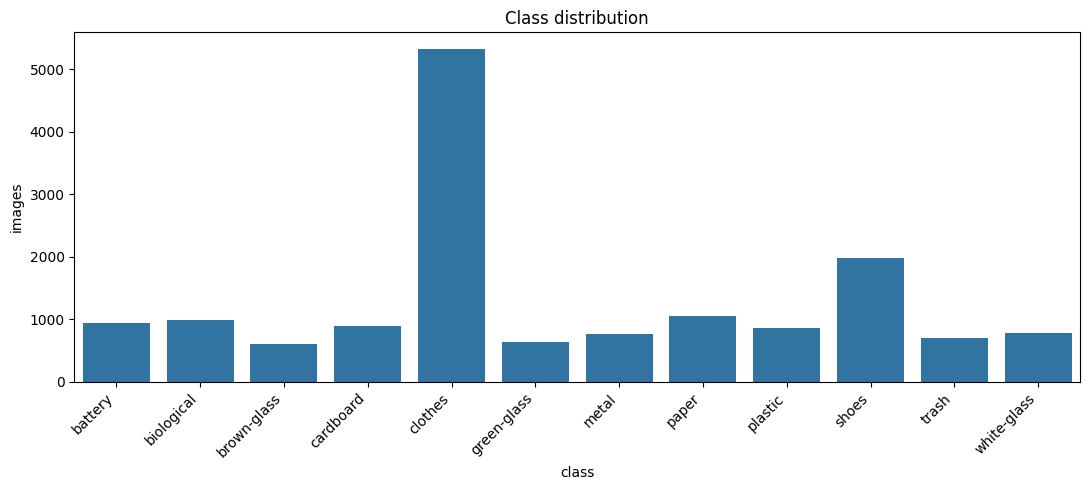

In [15]:
# 1. Data understanding and class distribution.
class_counts = class_image_counts(DATASET_ROOT)
class_names = sorted(class_counts.keys())
counts = {name: class_counts[name] for name in class_names}
counts_df = pd.DataFrame({'class': list(counts.keys()), 'images': list(counts.values())})
print('Total images:', counts_df['images'].sum())
display(counts_df)

plt.figure(figsize=(11, 5))
sns.barplot(data=counts_df, x='class', y='images')
plt.xticks(rotation=45, ha='right')
plt.title('Class distribution')
plt.tight_layout()
plt.show()

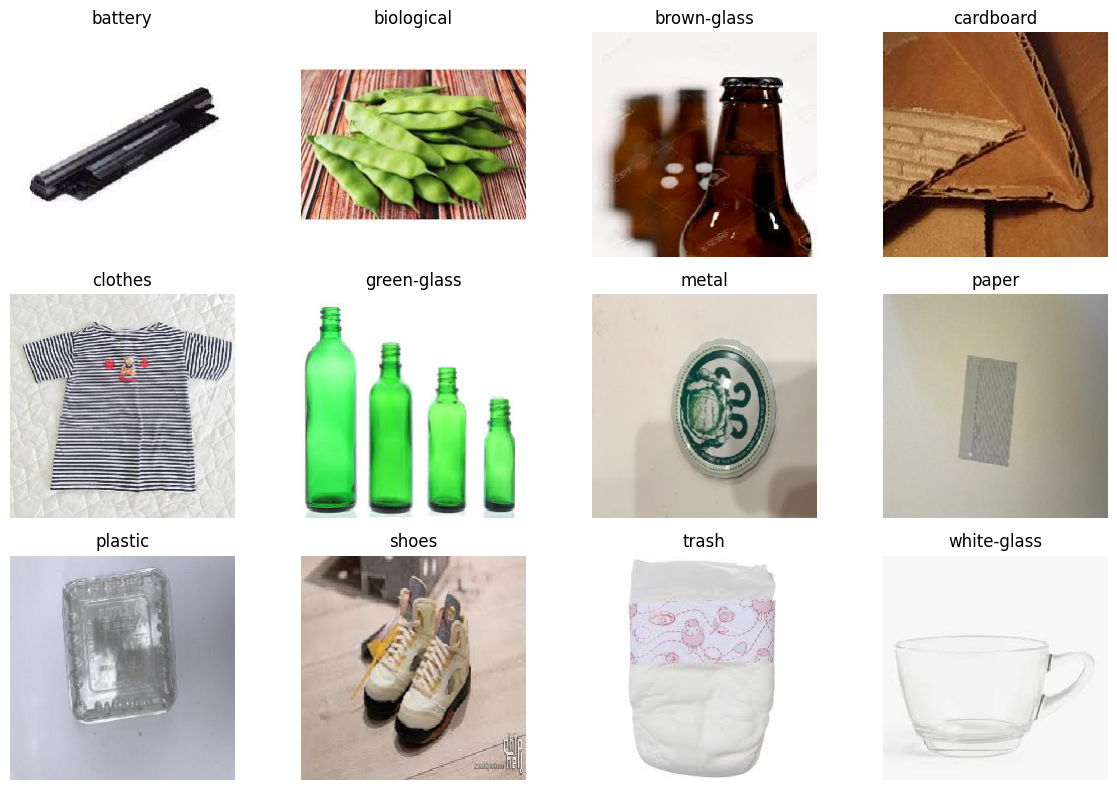

In [16]:
# Display sample images. Only choose actual image files, not directories.
def image_files_for_class(cls):
    folder = DATASET_ROOT / cls
    return [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]

plt.figure(figsize=(12, 8))
for i, cls in enumerate(class_names[:12]):
    files = image_files_for_class(cls)
    if not files:
        print(f'No image files found for class: {cls}')
        continue
    img_path = random.choice(files)
    img = tf.keras.utils.load_img(str(img_path), target_size=IMG_SIZE)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
# 80/20 training-validation split with deterministic seed.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
class_names = train_ds.class_names
num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
print(class_names)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


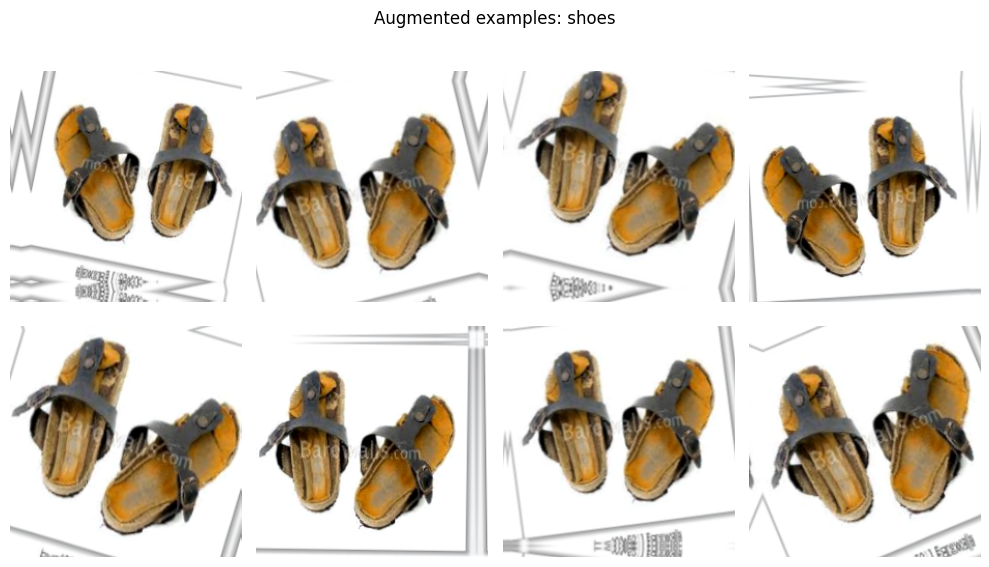

In [18]:
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set this to the folder that directly or indirectly contains your image class folders
DATASET_ROOT = pathlib.Path("/content/drive/MyDrive/AI/Waste Segregation Classification Dataset-20260509T132644Z-3-001")

IMG_SIZE = (224, 224)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# Find real image files anywhere inside DATASET_ROOT
all_images = [
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

if not all_images:
    raise FileNotFoundError(
        f"No image files found under {DATASET_ROOT}. Check your Google Drive path."
    )

sample_path = random.choice(all_images)

rescale = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.1),
], name="augmentation")

img = tf.keras.utils.load_img(str(sample_path), target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_batch = tf.expand_dims(img_array, axis=0)

plt.figure(figsize=(10, 6))
for i in range(8):
    aug = data_augmentation(img_batch, training=True)[0].numpy()
    aug = np.clip(aug, 0, 255).astype("uint8")

    plt.subplot(2, 4, i + 1)
    plt.imshow(aug)
    plt.axis("off")

plt.suptitle(f"Augmented examples: {sample_path.parent.name}")
plt.tight_layout()
plt.show()

In [19]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist[['loss', 'val_loss']].plot(ax=axes[0], title=f'{title}: loss')
    hist[['accuracy', 'val_accuracy']].plot(ax=axes[1], title=f'{title}: accuracy')
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, name):
    y_true, y_pred = [], []
    for x, y in dataset:
        probs = model.predict(x, verbose=0)
        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))
    print(name)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name}: confusion matrix')
    plt.tight_layout()
    plt.show()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {'model': name, 'accuracy': accuracy_score(y_true, y_pred), 'precision': precision, 'recall': recall, 'f1': f1}

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]

In [20]:
def build_baseline(num_classes):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = rescale(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='baseline_cnn')

baseline = build_baseline(num_classes=num_classes)  # pass your class count here

In [ ]:
# Initialize results list
results = []

# Compile, train, and evaluate the baseline model
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
baseline_time = time.time() - t0
plot_history(hist_baseline, 'Baseline CNN')
results.append(evaluate_model(baseline, val_ds, 'Baseline CNN'))
results[-1]['training_time_seconds'] = baseline_time

# Define build_deeper
def build_deeper(dropout=True, optimizer='adam'):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = rescale(x)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    if dropout:
        x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='deeper_cnn')
    if optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = keras.optimizers.Adam()

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train the deeper model with default Adam
deeper_adam = build_deeper(dropout=True, optimizer='adam')
t0 = time.time()
hist_deeper_adam = deeper_adam.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
deeper_adam_time = time.time() - t0
plot_history(hist_deeper_adam, 'Deeper CNN Adam')
results.append(evaluate_model(deeper_adam, val_ds, 'Deeper CNN Adam'))
results[-1]['training_time_seconds'] = deeper_adam_time


In [3]:
def build_deeper(dropout=True, optimizer='adam'):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = rescale(x)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    if dropout:
        x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='deeper_cnn')
    if optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    else:
        opt = keras.optimizers.Adam()

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [10]:
rescale = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.1),
], name="augmentation")


In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


In [ ]:
# 4. Transfer learning with MobileNetV2.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
base = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transfer = keras.Model(inputs, outputs, name='mobilenetv2_transfer')

transfer.compile(optimizer=keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
transfer.summary()

t0 = time.time()
hist_transfer = transfer.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
transfer_time = time.time() - t0

plot_history(hist_transfer, 'MobileNetV2 feature extraction')
results.append(evaluate_model(transfer, val_ds, 'MobileNetV2 transfer learning'))
results[-1]['training_time_seconds'] = transfer_time


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
242/388 ━━━━━━━━━━━━━━━━━━━━ 4:08 2s/step - accuracy: 0.6216 - loss: 1.2515

,true_label,pred_label,confidence,correct
0,paper,paper,0.998365,True
1,paper,paper,0.998400,True
2,clothes,clothes,0.999976,True
3,cardboard,cardboard,0.999956,True
4,trash,trash,0.998938,True
...,...,...,...,...
3098,shoes,shoes,0.996434,True
3099,trash,clothes,0.984568,False
3100,biological,biological,0.977577,True
3101,brown-glass,metal,0.549934,False


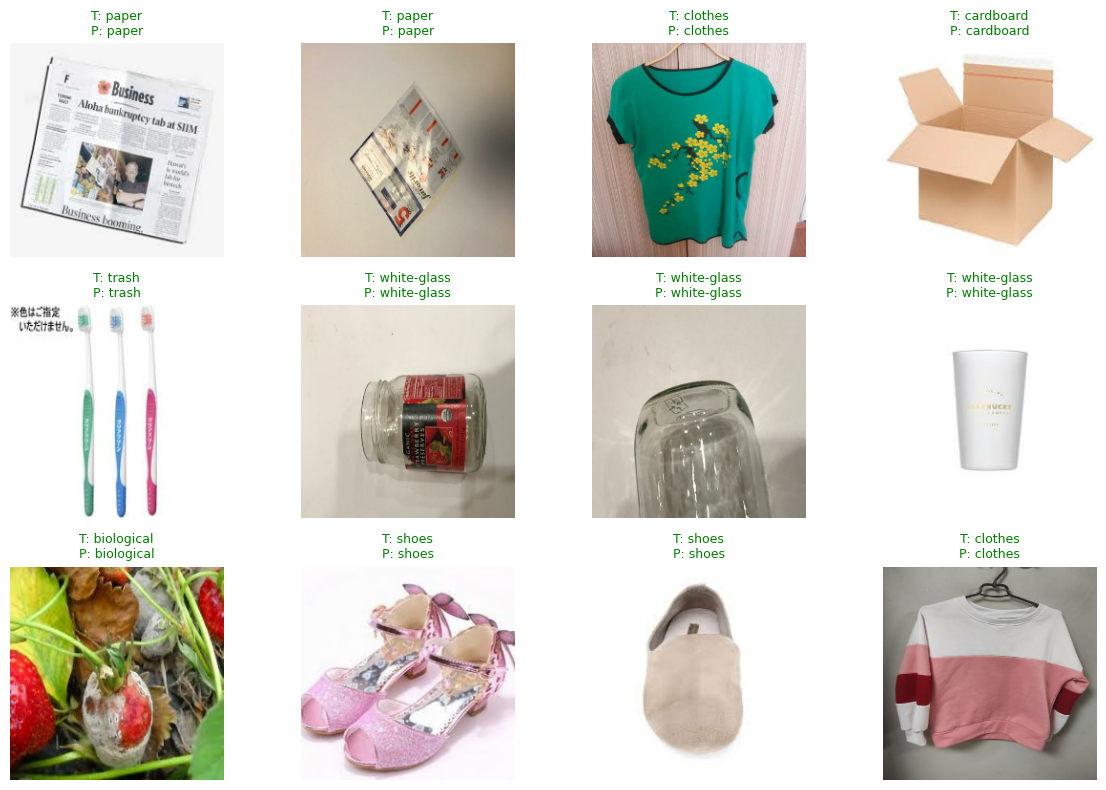

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ Define results list before using it
results = []

# Evaluate models and populate results
for images, labels in val_ds:
    probs = transfer.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(labels.numpy(), axis=1)
    for pred, true, prob in zip(preds, trues, probs):
        results.append({
            'true_label': class_names[true],
            'pred_label': class_names[pred],
            'confidence': np.max(prob),
            'correct': pred == true
        })

# Final comparison table for the report.
results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv('vision_model_comparison.csv', index=False)

# Sample inference plot.
for images, labels in val_ds.take(1):
    probs = transfer.predict(images, verbose=0)
    pred = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)
    plt.figure(figsize=(12, 8))
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        color = 'green' if pred[i] == true[i] else 'red'
        plt.title(f'T: {class_names[true[i]]}\nP: {class_names[pred[i]]}', color=color, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Report Notes

Use the generated CSV, plots, confusion matrices, model summaries, training times, and sample inference figure to complete the Part II Word report before exporting to PDF with the required naming convention.